# MachineLearning is all about
1. Getting data converted to numerical representation.
2. Building a model to learn pattern from numerical data made in step 1.

In [12]:
import torch

## step1: Create/load sample dataset

In [13]:
# y=mx+c
# y=dependent variable, x=independent variable, m=weight, c=bias

# assumed variables
weight = 0.7 # m
bias = 0.3 # c

# let's create a dataset
X = torch.arange(0,1,0.02).unsqueeze(dim=1) # add extra dimension
y = weight*X + bias
X[:5], y[:5], X.shape, y.shape

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]),
 torch.Size([50, 1]),
 torch.Size([50, 1]))

## step2: creat train & test data set

In [14]:
splitter = int(0.8*len(X))
splitter

40

In [15]:
x_train, y_train = X[:splitter], y[:splitter]
x_test, y_test = X[splitter:], y[splitter:]
x_train.shape

torch.Size([40, 1])

## step3: visualize data

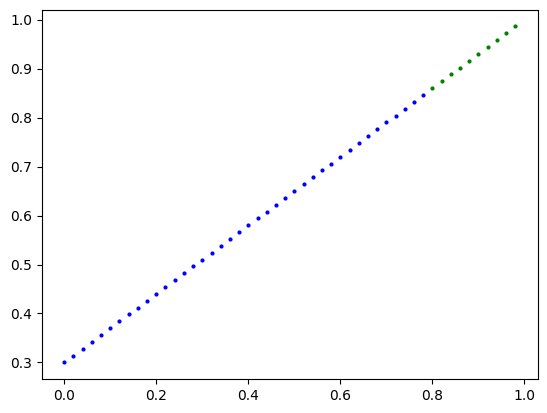

In [16]:
import matplotlib.pyplot as plt

plt.scatter(x_train, y_train, c='b', s=4)
plt.scatter(x_test, y_test, c='g', s=4)

## step4: build model

In [26]:
import torch
from torch import nn

#### What our model does:
1. `Start with random values, i.e., weights and bias.`
2. `Look at training data and adjust the random values to become a better representation of data.`

#### How it do so:
1. `Gradient descent.`
2. `Back Propagation.`

In [34]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        
    def forward(self,x:torch.tensor) -> torch.tensor:
        return self.weights * x + self.bias
        

## model building essentials
#### torch.nn (all building blocks here to make a graph)
#### torch.nn.parameters (what parameters should a model try and learn)
#### torch.nn.module (base class for all neural network models, including custom-made) | always overwrite the forward method
#### torch.optim (optimizers of PyTorch help in gradient descent)
#### def forward (defines what happens in forward computation)

## step5:check content of pytorch model

In [42]:
# create a random seed
ranadom_seed = 42
torch.manual_seed(ranadom_seed)

# create instance of class
model0 = LinearRegressionModel()
model0

LinearRegressionModel()

In [43]:
list(model0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [44]:
model0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

# aim is to make these weights=0.3367 and biases =0.1288 from the model to move values towards our assumed initial values, i.e., weight = 0.7, bias = 0.3

In [45]:
# inference mode
with torch.inference_mode():
    y_preds = model0(x_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])